# setup device

In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# setup SiameseDocumentDatasetm

In [2]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class SiameseDocumentDataset(Dataset):
    def __init__(self, split='train', transform=None, max_samples=None, allowed_classes=None,
                 max_samples_per_class=None):
        assert split in ["train", "test", "val"], "split must be 'train' or 'test' or 'val'"

        label_files = {
            'train': 'data/RVL_CDIP/labels/train.txt',
            'test': 'data/RVL_CDIP/labels/test.txt',
            "val": "data/RVL_CDIP/labels/val.txt"
        }

        root_dir = "data/RVL_CDIP/images"
        label_file = label_files[split]

        self.label_to_images = {}
        self.image_to_label = {}
        self.all_images = []

        self.allowed_classes = allowed_classes
        self.class_map = {cls: i for i, cls in enumerate(allowed_classes)} if allowed_classes else None

        with open(label_file, 'r') as f:
            for line in f:

                path, label = line.strip().split()
                full_path = os.path.join(root_dir, path)
                label = int(label)

                if allowed_classes is not None and label not in allowed_classes:
                    continue

                if label not in self.label_to_images:
                    self.label_to_images[label] = []

                if max_samples_per_class is not None and len(self.label_to_images[label]) >= max_samples_per_class:
                    continue

                if max_samples is not None and len(self) >= max_samples:
                    break

                self.label_to_images[label].append(full_path)
                self.image_to_label[full_path] = label
                self.all_images.append((full_path, label))

        self.labels = list(self.label_to_images.keys())
        self.transform = transform

    def num_classes(self):
        return len(self.label_to_images.keys())

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        img1_path, img1_class = self.all_images[idx]
        should_get_same_class = random.randint(0, 1)

        if should_get_same_class and len(self.label_to_images[img1_class]) > 1:
            img2_path = random.choice([
                path for path in self.label_to_images[img1_class] if path != img1_path
            ])
            img2_class = img1_class
            label = 0
        else:
            img2_class = random.choice([l for l in self.labels if l != img1_class])
            img2_path = random.choice(self.label_to_images[img2_class])
            label = 1

        img1 = Image.open(img1_path)
        img2 = Image.open(img2_path)

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        if self.class_map:
            img1_class = self.class_map[img1_class]  # z.B. 2 → 0, 6 → 1
            img2_class = self.class_map[img2_class]

        return img1, img2, label, img1_path, img2_path, img1_class, img2_class

# ALLOWED_CLASSES + create datasets and dataloader (test + train) + transform

In [3]:
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGE_SIZE = (224, 224)

# Define a basic transform
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),  # resize to a standard size
    transforms.ToTensor()  # convert to tensor
])

original_dataset_length = 0
with open("data/RVL_CDIP/labels/train.txt", "r") as f:
    original_dataset_length = sum(1 for _ in f)
print(original_dataset_length)

MAX_SAMPLES = original_dataset_length / 16

# ALLOWED_CLASSES = [4, 8]
# ALLOWED_CLASSES = [4, 7, 8, 12]
ALLOWED_CLASSES = [1, 2, 4, 7, 8, 11, 12, 14]

# NEW_ALLOWED_CLASSES = [4, 8, 12]
# NEW_ALLOWED_CLASSES = [4, 7, 8, 12, 14]
NEW_ALLOWED_CLASSES = [1, 2, 4, 7, 8, 10, 11, 12, 14]

BATCH_SIZE = 64
# Create the dataset instance
train_dataset = SiameseDocumentDataset(split='train', transform=transform, max_samples=MAX_SAMPLES,
                                       allowed_classes=ALLOWED_CLASSES)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = SiameseDocumentDataset(split="test", transform=transform, max_samples=1000,
                                      allowed_classes=ALLOWED_CLASSES)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


320000


## class_names

In [4]:
class_names = {
    0: "letter",
    1: "form",
    2: "email",
    3: "handwritten",
    4: "advertisement",
    5: "scientific report",
    6: "scientific publication",
    7: "specification",
    8: "file folder",
    9: "news article",
    10: "budget",
    11: "invoice",
    12: "presentation",
    13: "questionnaire",
    14: "resume",
    15: "memo"
}

## printing and plotting an example batch

In [5]:
# import matplotlib.pyplot as plt
#
# sample_batch = next(iter(train_dataloader))
#
# images1, images2, labels, paths1, paths2, class_labels1, class_labels2 = sample_batch
#
# # Plot the 8 pairs
# fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(6, 24))  # 8 pairs, 2 images each
#
# for i in range(8):
#     anc = images1[i].squeeze().numpy()
#     img2 = images2[i].squeeze().numpy()
#     label = labels[i].item()
#
#     actual_label_1 = ALLOWED_CLASSES[class_labels1[i]]
#     actual_label_2 = ALLOWED_CLASSES[class_labels2[i]]
#
#     # Print information for each pair
#     print(f"Pair {i + 1}")
#     print(f"Image 1 Path: {paths1[i]}")
#     print(f"Image 2 Path: {paths2[i]}")
#     print(f"Same class (0) or different (1): {label}")
#     print(f"Image 1 Class Label: {actual_label_1} (in words: {class_names[int(actual_label_1)]})")
#     print(f"Image 2 Class Label: {actual_label_2} (in words: {class_names[int(actual_label_2)]})")
#     print("-" * 50)
#
#     axes[i, 0].imshow(anc, cmap='gray')
#     axes[i, 0].set_title(f'Image 1\n(Label: {label})')
#     axes[i, 0].axis('off')
#
#     axes[i, 1].imshow(img2, cmap='gray')
#     axes[i, 1].set_title('Image 2')
#     axes[i, 1].axis('off')
#
# plt.tight_layout()
# plt.show()


# building the model

In [6]:
# import torch
# import torch.nn as nn
#
#
# class SiameseDocumentNetwork(nn.Module):
#     def __init__(self, input_shape: int, hidden_unit_multiplier: int, output_shape: int, image_size=(224, 224)):
#         super().__init__()
#         self.hum = hidden_unit_multiplier
#
#         self.cnn = nn.Sequential(
#             nn.Conv2d(input_shape, 8 * self.hum, kernel_size=11, padding=1, stride=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#
#             nn.Conv2d(8 * self.hum, 16 * self.hum, kernel_size=7, padding=1, stride=1),
#             nn.BatchNorm2d(16 * self.hum),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#
#             nn.Conv2d(16 * self.hum, 32 * self.hum, kernel_size=3, padding=1, stride=1),
#             nn.BatchNorm2d(32 * self.hum),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#
#             nn.Conv2d(32 * self.hum, 64 * self.hum, kernel_size=3, padding=1, stride=1),
#             nn.ReLU(),
#         )
#
#         with torch.inference_mode():
#             dummy_input = torch.zeros(1, input_shape, *image_size)
#             dummy_output = self.cnn(dummy_input)
#             flattened_size = dummy_output.view(1, -1).size(1)
#
#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(flattened_size, 128 * hidden_unit_multiplier),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128 * hidden_unit_multiplier, output_shape),  # Final embedding size
#         )
#
#     def forward_once(self, x):
#         x = self.cnn(x)
#         x = self.fc(x)
#         return F.normalize(x, p=2, dim=1)
#
#     def forward(self, input1, input2):
#         output1 = self.forward_once(input1)
#         output2 = self.forward_once(input2)
#         return output1, output2


In [7]:
import torch
from torch import nn
from torchvision import models


class ResNet18Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()
        self.model = models.resnet18()

        if input_shape == 1:
            self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, output_shape)

    def forward_once(self, x):
        x = self.model(x)
        return x

    # todo: forward method ändern (1 input)
    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2

# loss function(s)

In [8]:
import torch.nn.functional as F


class ContrastiveLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, x1, x2, label):
        # label == 0 if similar, label == 1 if different
        # Euclidean distance
        dist = F.pairwise_distance(x1, x2)

        loss = (1 - label) * torch.pow(dist, 2) \
               + label * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)

        # if label[0] == 0:
        #     print(f"same class loss: {loss[0]}")
        # else:
        #     print(f"diff class loss: {loss[0]}")

        return torch.mean(loss)

# training

## creating net, criterion and optimizer

In [9]:
from torch.utils.data import DataLoader

print(f"using {device}")
net = ResNet18Model(input_shape=1, output_shape=128).to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)

using cuda


## helper func, accuracy_fn()

In [10]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## train step

In [11]:
def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               clip_batches: int = 100,
               clip_norm: float = 2.0):
    train_loss = 0.0
    avg_loss = 0.0
    model.train()

    dataloader_progress = tqdm(dataloader, desc="Training...")
    for i, (img0, img1, label, _, _, _, _) in enumerate(dataloader_progress):
        img0, img1, label = img0.to(device), img1.to(device), label.float().to(device)

        output1, output2 = model(img0, img1)
        loss = criterion(output1, output2, label)

        optimizer.zero_grad()
        loss.backward()

        # Apply gradient clipping only for the first `clip_batches`
        if i < clip_batches:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)

        optimizer.step()

        train_loss += loss.item()
        avg_loss = train_loss / (i + 1)
        dataloader_progress.set_postfix(avg_loss=avg_loss)

    return avg_loss

## test step

In [12]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              criterion: nn.Module):
    test_loss = 0.0
    # model eval so Dropout Layer is disabled
    model.eval()
    dataloader_progress = tqdm(dataloader, desc="Testing...", colour="gray")

    with torch.inference_mode():
        for i, (img0, img1, label, _, _, _, _) in enumerate(dataloader_progress):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)

            output1, output2 = model(img0, img1)
            loss = criterion(output1, output2, label)

            test_loss += loss.item()
            avg_test_loss = test_loss / (i + 1)
            dataloader_progress.set_postfix(avg_loss=avg_test_loss)

    return avg_test_loss


## trying to load the model

In [13]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

skip_training = False
should_try_to_load_model = True  # True always skips training, False makes overwriting old training data possible

model_name_map = {
    2: "RVL_CDIP_siamese_model_2.pth",
    4: "RVL_CDIP_siamese_model_4.pth",
    8: "RVL_CDIP_siamese_model_8.pth",
}
MODEL_NAME = model_name_map.get(len(ALLOWED_CLASSES), "RVL_CDIP_Siamese_model_default.pth")
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

if MODEL_SAVE_PATH.exists() and should_try_to_load_model:
    print(f"loaded model: {MODEL_SAVE_PATH}, skipping training")
    net.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
    skip_training = True
else:
    if should_try_to_load_model:
        print(f"{MODEL_SAVE_PATH} does not exist, continuing to training")
    else:
        print("loading a model was not desired, continuing to training")
    skip_training = False

loaded model: models\RVL_CDIP_siamese_model_8.pth, skipping training


## training loop

In [14]:
# helper func
def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes}m {seconds}s"

In [15]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

# Training loop with tqdm progress bar
num_epochs = 2

if not skip_training:
    for epoch in range(num_epochs):
        start = timer()

        print(f"Epoch {epoch + 1}/{num_epochs}: Training...")
        train_step(model=net, dataloader=train_dataloader, criterion=criterion, optimizer=optimizer)
        print(f"Epoch {epoch + 1}/{num_epochs}: Testing...")
        test_step(net, test_dataloader, criterion)

        total_epoch_elapsed = timer() - start
        remaining_time = total_epoch_elapsed * (num_epochs - epoch - 1)
        print(
            f"Epoch duration: {format_time(total_epoch_elapsed)}. "
            f"Estimated remaining time: {format_time(remaining_time)}."
        )
else:
    print(f"loaded a model, skipping training")

loaded a model, skipping training


# Save the model

In [16]:
# falls trainiert wurde, speichern, sonst nichts tun
if not skip_training:
    print(f"saving model: {MODEL_SAVE_PATH}")
    torch.save(obj=net.state_dict(), f=MODEL_SAVE_PATH)

# evaluation

In [17]:
import torch.nn.functional as F
import matplotlib.pyplot as plt


def visualize_siamese_distances(model, dataloader, device, allowed_classes, max_pairs=8):
    """
    Visualizes Euclidean distances between image pairs with true labels (Same/Diff).
    """
    model.eval()

    with torch.inference_mode():
        for img1, img2, labels, _, _, class_labels1, class_labels2 in dataloader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            # Get embeddings
            emb1, emb2 = model(img1, img2)

            # Compute Euclidean distances
            dists = F.pairwise_distance(emb1, emb2)

            num_pairs = min(max_pairs, len(labels))
            fig, axes = plt.subplots(num_pairs, 2, figsize=(6, 3 * num_pairs))
            if num_pairs == 1:
                axes = [axes]

            for i in range(num_pairs):
                dist = dists[i].item()
                label = labels[i].item()
                label_text = "Same" if label == 0 else "Diff"

                axes[i][0].imshow(img1[i].cpu().squeeze(), cmap='gray')
                axes[i][0].set_title(f"Image 1: {class_names[allowed_classes[class_labels1[i]]]}")
                axes[i][0].axis('off')

                axes[i][1].imshow(img2[i].cpu().squeeze(), cmap='gray')
                axes[i][1].set_title(
                    f"Image 2: {class_names[allowed_classes[class_labels2[i]]]}\nTrue: {label_text} | Dist: {dist:.2f}")
                axes[i][1].axis('off')

            plt.tight_layout()
            plt.show()
            break  # Remove to view more batches


## example pairs

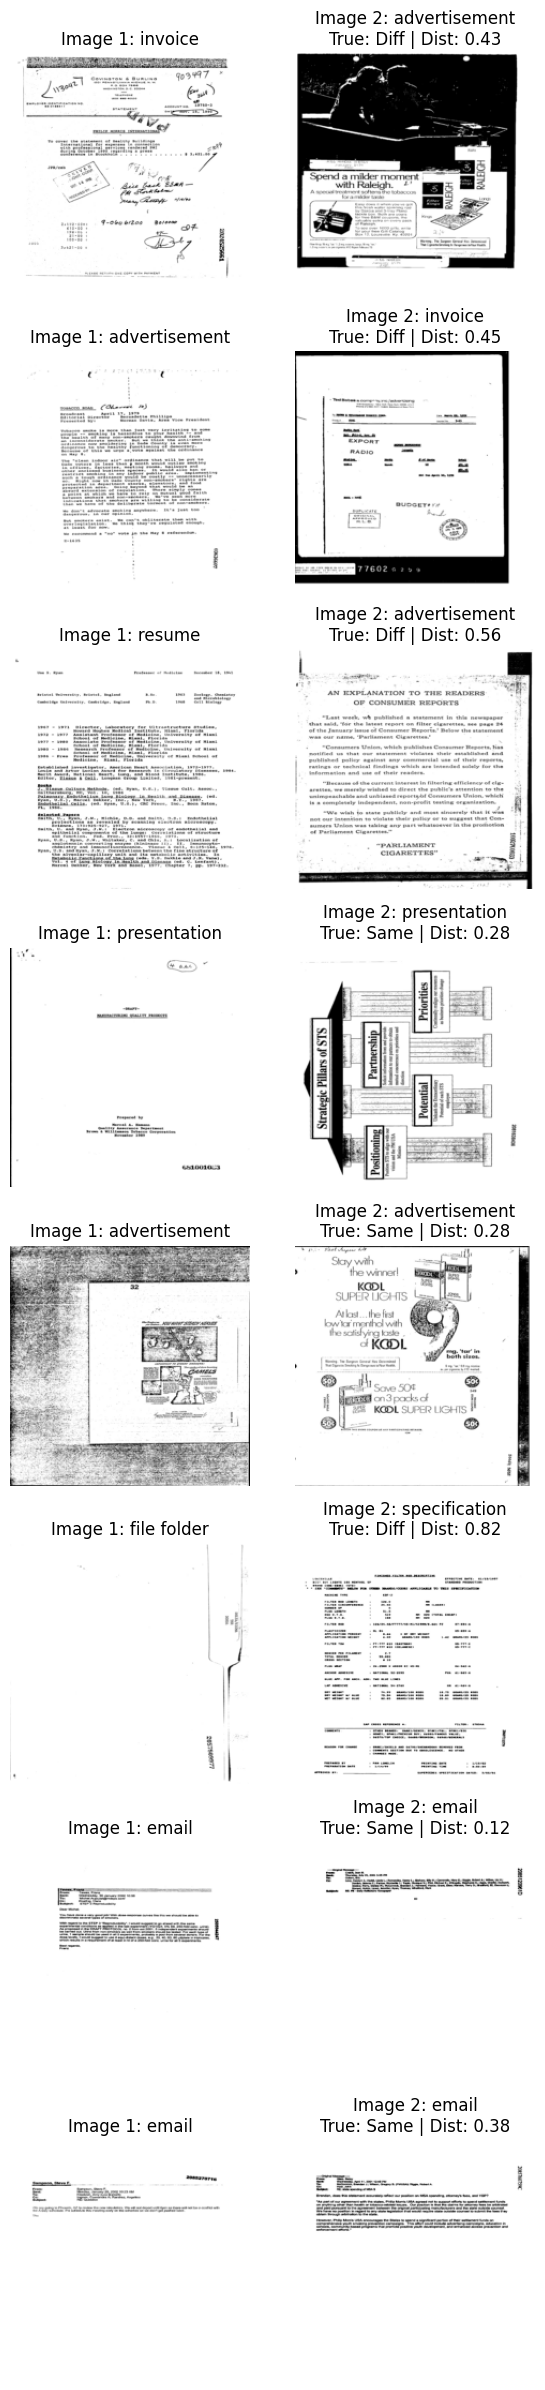

In [18]:
val_dataset = SiameseDocumentDataset(split="val", transform=transform, max_samples=5000,
                                     allowed_classes=ALLOWED_CLASSES)
val_dataloader = DataLoader(dataset=val_dataset, shuffle=False, batch_size=8)
visualize_siamese_distances(net, val_dataloader, device, allowed_classes=ALLOWED_CLASSES, max_pairs=8)

In [19]:
import torch
import torch.nn.functional as F
import numpy as np


def compute_average_distance(model, dataloader, device, max_batches=None):
    model.eval()
    all_dists = []

    with torch.inference_mode():
        for i, (img1, img2, *_) in enumerate(dataloader):
            img1, img2 = img1.to(device), img2.to(device)
            emb1, emb2 = model(img1, img2)
            dists = F.pairwise_distance(emb1, emb2)

            all_dists.extend(dists.cpu().numpy())

            if max_batches is not None and i + 1 >= max_batches:
                break

    avg_distance = np.mean(all_dists)
    print(f"Average distance (all pairs): {avg_distance:.3f}")
    return avg_distance


In [20]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def plot_distance_histogram(model, dataloader, device, max_batches=None, bins=50, threshold=0.5):
    model.eval()
    same_dists = []
    diff_dists = []

    correct_same = 0
    total_same = 0
    correct_diff = 0
    total_diff = 0

    with torch.inference_mode():
        for i, (img1, img2, labels, _, _, _, _) in enumerate(dataloader):
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            emb1, emb2 = model(img1, img2)
            dists = F.pairwise_distance(emb1, emb2)

            dists_np = dists.cpu().numpy()
            labels_np = labels.cpu().numpy()

            for dist, label in zip(dists_np, labels_np):
                if label == 0:
                    same_dists.append(dist)
                    total_same += 1
                    if dist < threshold:
                        correct_same += 1
                else:
                    diff_dists.append(dist)
                    total_diff += 1
                    if dist >= threshold:
                        correct_diff += 1

            if max_batches is not None and i + 1 >= max_batches:
                break

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(same_dists, bins=bins, alpha=0.6, label='Same Class', color='green')
    plt.hist(diff_dists, bins=bins, alpha=0.6, label='Different Class', color='red')
    plt.axvline(x=threshold, color='blue', linestyle='--', label=f'Threshold = {threshold:.5f}')
    plt.xlabel("Euclidean Distance")
    plt.ylabel("Number of Pairs")
    plt.title("Distribution of Pairwise Distances")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    same_accuracy = (correct_same / total_same * 100) if total_same > 0 else 0
    diff_accuracy = (correct_diff / total_diff * 100) if total_diff > 0 else 0
    overall_accuracy = ((correct_same + correct_diff) / (total_same + total_diff) * 100)

    print(f"Avg distance (same): {np.mean(same_dists):.3f}")
    print(f"Avg distance (diff): {np.mean(diff_dists):.3f}")
    print(f"Accuracy (same class): {same_accuracy:.2f}%")
    print(f"Accuracy (different class): {diff_accuracy:.2f}%")
    print(f"Overall accuracy: {overall_accuracy:.2f}%")

## distance histogram

In [21]:
# thres = compute_average_distance(net, val_dataloader, device, 300)
# plot_distance_histogram(net, val_dataloader, device, 300, threshold=thres)

In [22]:
print("OLD ALLOWED CLASSES:")
for class_id in ALLOWED_CLASSES:
    print(f"{class_id}: {class_names[class_id]}")

print("\nNEW ALLOWED CLASSES: ")
for class_id in NEW_ALLOWED_CLASSES:
    print(f"{class_id}: {class_names[class_id]}")

OLD ALLOWED CLASSES:
1: form
2: email
4: advertisement
7: specification
8: file folder
11: invoice
12: presentation
14: resume

NEW ALLOWED CLASSES: 
1: form
2: email
4: advertisement
7: specification
8: file folder
10: budget
11: invoice
12: presentation
14: resume


In [23]:
# added_class_val_dataset = SiameseDocumentDataset(split="val", transform=transform, max_samples=5000,
#                                                  included_classes=NEW_ALLOWED_CLASSES)
# added_class_val_dataloader = DataLoader(dataset=added_class_val_dataset, shuffle=False, batch_size=BATCH_SIZE)
# visualize_siamese_distances(net, added_class_val_dataloader, device, included_classes=NEW_ALLOWED_CLASSES, max_pairs=8)

In [24]:
# thres_after_adding_class = compute_average_distance(net, added_class_val_dataloader, device, 300)
# plot_distance_histogram(net, added_class_val_dataloader, device, 300, threshold=thres_after_adding_class)

# creating a testset with known classes

In [25]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class TemplateDatasetOfClass(Dataset):
    def __init__(self, cls: int, max_samples_per_class=1, transform=None, strategy=None, search_count=2000):

        assert strategy in [None, "RANDOM", "FAR"], "strategy must be RANDOM or FAR"

        root_dir = "data/RVL_CDIP/images"
        label_file = "data/RVL_CDIP/labels/val.txt"

        self.all_image_paths = []
        self.cls = cls

        self.transform = transform

        with open(label_file, 'r') as f:
            for line in f:
                path, label = line.strip().split()
                full_path = os.path.join(root_dir, path)
                label = int(label)

                if label != cls:
                    continue

                if len(self.all_image_paths) >= max_samples_per_class:
                    # print("finished")
                    break

                if len(self.all_image_paths) >= 1 and strategy == "FAR":
                    current_imgs = [Image.open(path) for path, _ in self.all_image_paths]
                    current_imgs = [self.transform(img).to(device) for img in current_imgs]
                    current_imgs = [img.unsqueeze(0) for img in current_imgs]

                    highest_dist = 0
                    final_choice = None
                    for i, line in enumerate(f):
                        if search_count is not None and i >= search_count and final_choice is not None:
                            break
                        path, label = line.strip().split()
                        full_path = os.path.join(root_dir, path)
                        label = int(label)
                        if label != cls:
                            continue
                        new_img = Image.open(full_path)
                        new_img = self.transform(new_img).to(device)
                        new_img = new_img.unsqueeze(0)

                        avg_dist = 0
                        for img in current_imgs:
                            emb1, emb2 = net(img, new_img)
                            avg_dist += F.pairwise_distance(emb1, emb2)
                        avg_dist /= len(current_imgs)

                        if avg_dist > highest_dist:
                            highest_dist = avg_dist
                            final_choice = full_path
                    # print(f"final choice: {final_choice}, distance to previous imgs: {highest_dist}")
                    self.all_image_paths.append((final_choice, label))
                else:
                    self.all_image_paths.append((full_path, label))

    def get_class(self):
        return self.cls

    def __len__(self):
        return len(self.all_image_paths)

    def __getitem__(self, idx):
        img_path, img_class = self.all_image_paths[idx]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        img_class = 0
        return img, img_class

    def get_all_items(self):
        imgs = []
        for img_path, _ in self.all_image_paths:
            img = Image.open(img_path)

            if self.transform:
                img = self.transform(img)  # PIL -> Tensor (C,H,W)

            imgs.append(img)

        return imgs

# template count

In [26]:
print(ALLOWED_CLASSES)
print(NEW_ALLOWED_CLASSES)

TEMPLATE_COUNT = 5
TEMPLATE_STRATEGY = "FAR"


def create_datasets(list_of_classes, max_templates, transform=None, strategy=None):
    datasets = []
    for cls in list_of_classes:
        datasets.append(
            TemplateDatasetOfClass(cls, max_samples_per_class=max_templates, transform=transform, strategy=strategy,
                                   search_count=500))
    return datasets


NEW_CLASSES_ONLY = list(set(NEW_ALLOWED_CLASSES) - set(ALLOWED_CLASSES))
print(NEW_CLASSES_ONLY)

known_class_datasets = create_datasets(ALLOWED_CLASSES, max_templates=TEMPLATE_COUNT, transform=transform,
                                       strategy=TEMPLATE_STRATEGY)
unknown_class_datasets = create_datasets(NEW_CLASSES_ONLY, max_templates=20, transform=transform)

[1, 2, 4, 7, 8, 11, 12, 14]
[1, 2, 4, 7, 8, 10, 11, 12, 14]
[10]


# trying to predict an img of an unknown class

In [27]:
def predict_class_of_img(model: nn.Module, img, known_class_datasets, threshold=0.5, give_raw_value=False):
    """

    :param model: the model making the predictions
    :param img: image to be predicted on (shape must be [1, 1, 224, 224])
    :param known_class_datasets: list of datasets where the templates live
    :param threshold: threshold defining how confident the model must be to predict a class
    :return: the predicted class (0-15) of the given image, if no prediction could be made confidently it returns -1
    """
    assert img.shape == torch.Size(
        [1, 1, 224, 224]), "image shape must be [1, 1, 224, 224], hint: an unsqueeze(0) could fix it"
    model.eval()

    best_class = None
    best_mean_dist = float("inf")

    with torch.inference_mode():
        for cls_data in known_class_datasets:

            cls_data_dists = []
            for img2 in cls_data.get_all_items():
                img2 = img2.unsqueeze(0)  # Batch dimension für model hinzufügen

                img, img2 = img.to(device), img2.to(device)
                emb1, emb2 = model(img, img2)
                dists = F.pairwise_distance(emb1, emb2)

                cls_data_dists.append(dists)

            # TODO: try using lowest distance instead of mean distance
            mean_dist = torch.cat(cls_data_dists, dim=0).mean().item()
            # mean_dist = torch.cat(cls_data_dists, dim=0).min().item()
            if mean_dist <= best_mean_dist:
                best_mean_dist = mean_dist
                best_class = cls_data.get_class()

        if give_raw_value:
            return best_mean_dist

        if best_mean_dist > threshold:
            # print(
            #     f"smallest distance ({best_mean_dist:.5f}) is still higher than threshold ({threshold}). Too unsure to predict a class")
            return -1
        else:
            # print(
            #     f"smallest distance ({best_mean_dist:.5f}) smaller than threshold ({threshold}). Predicting class: {best_class} (in words: {class_names[best_class]})")
            return best_class


### giving the model one image to predict on

In [28]:
def print_pred(pred):
    if pred == -1:
        print(f"{pred}: unknown")
    else:
        print(f"{pred}: {class_names[pred]}")

In [29]:
# unknown_class_img = unknown_class_datasets[0].get_all_items()[0]
# unknown_class_name = class_names[unknown_class_datasets[0].get_class()]
# plt.title(f"first img of unknown class: {unknown_class_name}")
# plt.imshow(unknown_class_img.squeeze(), cmap="gray")
# plt.axis("off")
# plt.show()
# pred = predict_class_of_img(net, unknown_class_img.unsqueeze(0), known_class_datasets)
# print_pred(pred)
#
# known_class_img = known_class_datasets[0].get_all_items()[0]
# known_class_name = class_names[known_class_datasets[0].get_class()]
# plt.title(f"first img of one of the learned classes: {known_class_name}")
# plt.imshow(unknown_class_img.squeeze(), cmap="gray")
# plt.axis("off")
# plt.show()
# pred = predict_class_of_img(net, known_class_img.unsqueeze(0), known_class_datasets)
# print_pred(pred)

In [30]:
# print(f"predictions on unknown classes")
# for cls_data in unknown_class_datasets:
#     for img in cls_data.get_all_items():
#         pred = predict_class_of_img(net, img.unsqueeze(0), known_class_datasets, threshold=0.05)
#         true = cls_data.get_class()
#         eval_string = f"correct" if pred == true or (pred == -1 and true not in ALLOWED_CLASSES) else f"wrong"
#         print(f"pred: {pred}, true: {cls_data.get_class()}, model was {eval_string}")
#
# print(f"predictions on learned classes")
# for cls_data in known_class_datasets:
#     for img in cls_data.get_all_items():
#         pred = predict_class_of_img(net, img.unsqueeze(0), known_class_datasets, threshold=0.05)
#         true = cls_data.get_class()
#         eval_string = f"correct" if pred == true or (pred == -1 and true not in ALLOWED_CLASSES) else f"wrong"
#         print(f"pred: {pred}, true: {cls_data.get_class()}, model was {eval_string}")

## preparing to make predictions for the confusion matrix

In [31]:
dataset_with_new_classes = SiameseDocumentDataset(
    allowed_classes=NEW_ALLOWED_CLASSES,
    split="val",
    transform=transform,
    max_samples_per_class=50
)
dataloader_with_new_classes = DataLoader(
    dataset=dataset_with_new_classes,
    batch_size=1,
    shuffle=False
)

for label, images in dataset_with_new_classes.label_to_images.items():
    print(f"Label: {label}, Anzahl Bilder: {len(images)}")

Label: 11, Anzahl Bilder: 50
Label: 4, Anzahl Bilder: 50
Label: 14, Anzahl Bilder: 50
Label: 12, Anzahl Bilder: 50
Label: 10, Anzahl Bilder: 50
Label: 8, Anzahl Bilder: 50
Label: 2, Anzahl Bilder: 50
Label: 1, Anzahl Bilder: 50
Label: 7, Anzahl Bilder: 50


## making predictions for the confusion matrix

In [32]:
## computing the average confidence of known images

dataset_with_old_classes = SiameseDocumentDataset(allowed_classes=ALLOWED_CLASSES, split="val", transform=transform,
                                                  max_samples_per_class=50)
dataloader_with_old_classes = DataLoader(dataset=dataset_with_old_classes, batch_size=1, shuffle=False)

dists = []
net.eval()
with torch.inference_mode():
    for batch in dataloader_with_old_classes:
        img1, img2, _, _, _, img1_class, img2_class = batch
        original_cls1 = ALLOWED_CLASSES[img1_class]
        original_cls2 = ALLOWED_CLASSES[img2_class]

        dist1 = predict_class_of_img(net, img1, known_class_datasets, give_raw_value=True)
        dist2 = predict_class_of_img(net, img2, known_class_datasets, give_raw_value=True)
        dists.append(dist1)
        dists.append(dist2)

In [33]:
mean_dist = np.mean(dists)
print(mean_dist)

0.4117337138578296



================= Threshold: 0.3617337138578296 =================


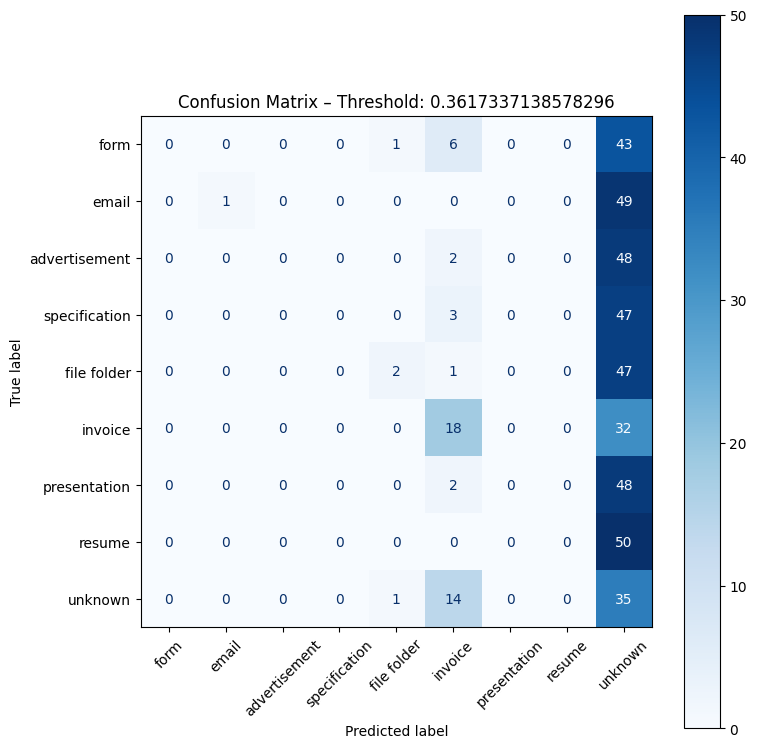

C:\Users\lhuen\PycharmProjects\MNIST-SiameseNetwork\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Klasse 'form':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'email':
  -> Recall:    2.00%
  -> Precision: 100.00%
Klasse 'advertisement':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'specification':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'file folder':
  -> Recall:    4.00%
  -> Precision: 50.00%
Klasse 'invoice':
  -> Recall:    36.00%
  -> Precision: 39.13%
Klasse 'presentation':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'resume':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'unknown':
  -> Recall:    70.00%
  -> Precision: 8.77%

================= Threshold: 0.4117337138578296 =================


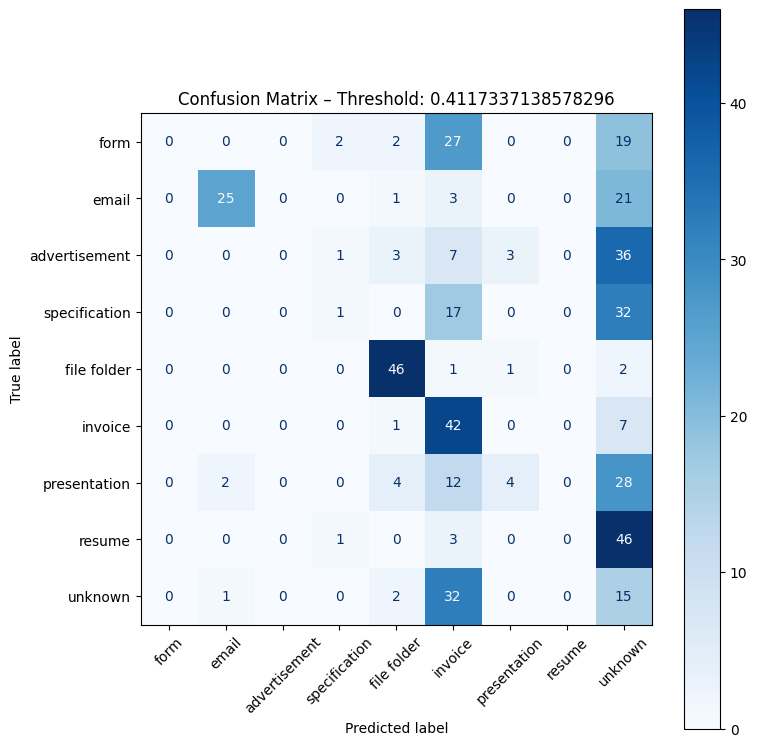

C:\Users\lhuen\PycharmProjects\MNIST-SiameseNetwork\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Klasse 'form':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'email':
  -> Recall:    50.00%
  -> Precision: 89.29%
Klasse 'advertisement':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'specification':
  -> Recall:    2.00%
  -> Precision: 20.00%
Klasse 'file folder':
  -> Recall:    92.00%
  -> Precision: 77.97%
Klasse 'invoice':
  -> Recall:    84.00%
  -> Precision: 29.17%
Klasse 'presentation':
  -> Recall:    8.00%
  -> Precision: 50.00%
Klasse 'resume':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'unknown':
  -> Recall:    30.00%
  -> Precision: 7.28%

================= Threshold: 0.4617337138578296 =================


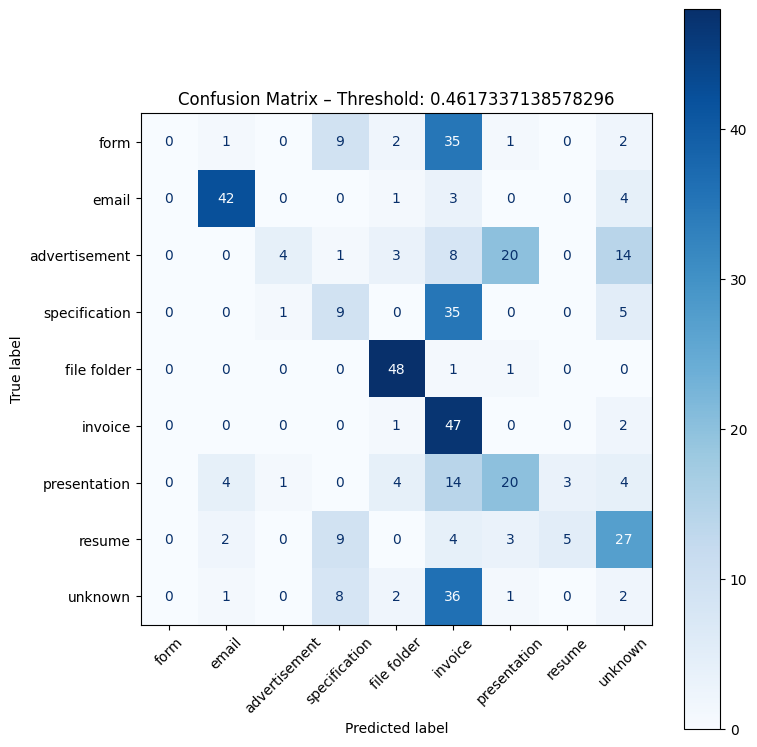

Klasse 'form':
  -> Recall:    0.00%
  -> Precision: 0.00%
Klasse 'email':
  -> Recall:    84.00%
  -> Precision: 84.00%
Klasse 'advertisement':
  -> Recall:    8.00%
  -> Precision: 66.67%
Klasse 'specification':
  -> Recall:    18.00%
  -> Precision: 25.00%
Klasse 'file folder':
  -> Recall:    96.00%
  -> Precision: 78.69%
Klasse 'invoice':
  -> Recall:    94.00%
  -> Precision: 25.68%
Klasse 'presentation':
  -> Recall:    40.00%
  -> Precision: 43.48%
Klasse 'resume':
  -> Recall:    10.00%
  -> Precision: 62.50%
Klasse 'unknown':
  -> Recall:    4.00%
  -> Precision: 3.33%


C:\Users\lhuen\PycharmProjects\MNIST-SiameseNetwork\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score
import matplotlib.pyplot as plt
from collections import Counter

class_to_idx = {cls: i for i, cls in enumerate(ALLOWED_CLASSES)}
idx_to_class = dict(enumerate(NEW_ALLOWED_CLASSES))
unknown_id = -1

# Thresholds definieren
THRESHOLDS = [mean_dist - 0.05, mean_dist, mean_dist + 0.05]
MAX_IMAGES = 100000
strategy_prefix = "r" if TEMPLATE_STRATEGY == "RANDOM" else "f" if TEMPLATE_STRATEGY == "FAR" else "x"
FILE_PREFIX = f"{len(ALLOWED_CLASSES)}_{TEMPLATE_COUNT}{strategy_prefix}"

# Optional: Verzeichnis zum Speichern der Plots
os.makedirs("confusion_matrices", exist_ok=True)
output_file = os.path.join("confusion_matrices", f"{FILE_PREFIX}_metrics.txt")
with open(output_file, "w", encoding="utf-8") as f:
    for THRESHOLD in THRESHOLDS:
        print(f"\n================= Threshold: {THRESHOLD} =================")
        f.write(f"\n================= Threshold: {THRESHOLD} =================\n")

        all_preds, all_labels = [], []
        img_count = 0

        net.eval()
        with torch.inference_mode():
            for batch in dataloader_with_new_classes:
                img1, _, _, _, _, img1_class, _ = batch

                for img, lbl_idx in zip(img1, img1_class):
                    if img_count >= MAX_IMAGES:
                        break

                    original_cls = idx_to_class[lbl_idx.item()]
                    mapped_true = class_to_idx.get(original_cls, unknown_id)
                    all_labels.append(mapped_true)

                    img = img.unsqueeze(0).to(device)
                    pred_cls = predict_class_of_img(net, img, known_class_datasets, threshold=THRESHOLD)
                    mapped_pred = class_to_idx.get(pred_cls, unknown_id) if pred_cls != -1 else unknown_id
                    all_preds.append(mapped_pred)

                    img_count += 1
                if img_count >= MAX_IMAGES:
                    break

        known_ids = list(class_to_idx.values())
        all_ids = known_ids + [unknown_id]
        label_names = [class_names[c] for c in ALLOWED_CLASSES] + ["unknown"]

        cm = confusion_matrix(all_labels, all_preds, labels=all_ids)

        fig, ax = plt.subplots(figsize=(8, 8))
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
        disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
        plt.title(f"Confusion Matrix – Threshold: {THRESHOLD}")
        plt.tight_layout()
        plt.savefig(f"confusion_matrices/{FILE_PREFIX}_{int(THRESHOLD * 100):02d}.png")
        plt.show()

        recall_per_class = recall_score(all_labels, all_preds, labels=all_ids, average=None)
        precision_per_class = precision_score(all_labels, all_preds, labels=all_ids, average=None)

        for i, class_name in enumerate(label_names):
            recall_str = f"{recall_per_class[i]:.2%}"
            precision_str = f"{precision_per_class[i]:.2%}"
            print(f"Klasse '{class_name}':")
            print(f"  -> Recall:    {recall_str}")
            print(f"  -> Precision: {precision_str}")
            f.write(f"Klasse '{class_name}':\n")
            f.write(f"  -> Recall:    {recall_str}\n")
            f.write(f"  -> Precision: {precision_str}\n")

